# Laboratorio 1
**Redes Neuronales para Lenguaje Natural, 2026**

Este laboratorio está basado en [TA1C (Te Ahorré Un Click)](https://www.fing.edu.uy/inco/grupos/pln/ta1c/), una competencia organizada en IberLEF 2025 por el grupo PLN del Inco, centrada en la detección y resolución de clickbait en noticias en español. Se considera clickbait a un texto que omite deliberadamente parte de la información con el objetivo de generar curiosidad y motivar al lector a acceder a la noticia.

En particular, trabajaremos sobre la subtarea de detección de clickbait, formulada como un problema de clasificación binaria. A partir del texto de un tweet que contiene el titular de una noticia, el objetivo será determinar si es clickbait o no.

A lo largo del laboratorio construiremos distintos clasificadores basados en redes neuronales para resolver esta tarea, con el objetivo de explorar el uso de word embeddings y comparar distintas arquitecturas de redes neuronales.

**Entrega: 5 de octubre de 2026**

**Formato: notebook de Python (.ipynb)**

**No olvidar mantener todas las salidas de cada región de código en el notebook!**

---



## 0. Preparación del entorno

Comenzamos con algunos imports y definiciones.

In [1]:
! pip install --upgrade gensim
! pip install --upgrade torch
import re
import unicodedata
import gensim.downloader as api
import nltk
from nltk.corpus import stopwords
# Descarga el recurso de stop words (si no existe, lo baja una sola vez).
nltk.download("stopwords", quiet=True)

import torch
import gensim
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix

CLICKBAIT_LABELS = ['No','Clickbait']
CLICKBAIT_ID = {p:i for (i,p) in enumerate(CLICKBAIT_LABELS) }

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59

Descargamos el dataset de titulares de noticias, que incluye la anotación binaria en clickbait o no. Por más información sobre el dataset, consulte [aquí](https://github.com/pln-fing-udelar/pln-inco-resources/tree/master/clickbait/iberlef2025/detection).

In [13]:
from pathlib import Path
from urllib.request import urlretrieve

# Lista de archivos del dataset a descargar
urls = [
    "https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/clickbait/iberlef2025/detection/TA1C_dataset_detection_train.csv",
    "https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/clickbait/iberlef2025/detection/TA1C_dataset_detection_dev_gold.csv",
    "https://raw.githubusercontent.com/pln-fing-udelar/pln-inco-resources/master/clickbait/iberlef2025/detection/TA1C_dataset_detection_test_gold.csv",
]

# Descarga cada archivo y lo guarda con su nombre original
for url in urls:
    filename = Path(url).name
    print(f"Descargando {filename}...")
    urlretrieve(url, filename)
    print(f"OK: {filename}")

Descargando TA1C_dataset_detection_train.csv...
OK: TA1C_dataset_detection_train.csv
Descargando TA1C_dataset_detection_dev_gold.csv...
OK: TA1C_dataset_detection_dev_gold.csv
Descargando TA1C_dataset_detection_test_gold.csv...
OK: TA1C_dataset_detection_test_gold.csv


Cargamos las tres particiones del dataset (train, dev, test) en dataframes de pandas.
Cada partición está compuesta por titulares de noticias sacados de tweets. Para cada noticia tenemos el texto extraído del tweet (el titular) y si es clickbait o no, con las categorías: No, Clickbait. Además, el dataset incluye la fecha de la noticia e información sobre el medio y país de origen, que descartamos.

In [12]:
from sklearn.model_selection import train_test_split

# Cargamos unicamente las columnas necesarias y renombramos a nombres consistentes
train_df = pd.read_csv('./TA1C_dataset_detection_train.csv', usecols=["Teaser Text", "Tag Value"])
train_df = train_df.rename(columns={"Teaser Text": "text", "Tag Value": "label"})

dev_df = pd.read_csv('./TA1C_dataset_detection_dev_gold.csv', usecols=["Teaser Text", "Tag Value"])
dev_df = dev_df.rename(columns={"Teaser Text": "text", "Tag Value": "label"})

test_df = pd.read_csv('./TA1C_dataset_detection_test_gold.csv', usecols=["Teaser Text", "Tag Value"])
test_df = test_df.rename(columns={"Teaser Text": "text", "Tag Value": "label"})

# Verificacion basica de tamanos
print("Training set size:", len(train_df))
print("Development set size:", len(dev_df))
print("Test set size:", len(test_df))

# Inspeccion rapida de un ejemplo
display(train_df.iloc[0].text)
display(train_df.iloc[0].label)

Training set size: 2800
Development set size: 700
Test set size: 700


'#SegundaDivisión  | La fortaleza del ataque: Rampla Juniors terminó con el invicto de Rocha'

'No'

En este laboratorio utilizaremos el titular como entrada (columna "text"), y la categoría binaria (columna "label").

Imprimimos algunos textos de ejemplo y sus categorías, y luego imprimimos la cantidad de ejemplos de las dos clases en las tres particiones.

In [11]:
# Extraemos el texto de cada particion como arrays de numpy
train_text = train_df.loc[:, 'text'].to_numpy()
dev_text = dev_df.loc[:, 'text'].to_numpy()
test_text = test_df.loc[:, 'text'].to_numpy()

# Convertimos etiquetas string (No/Clickbait) a ids numericos (0/1)
train_labels = np.array([CLICKBAIT_ID[l] for l in train_df.loc[:, 'label']])
dev_labels = np.array([CLICKBAIT_ID[l] for l in dev_df.loc[:, 'label']])
test_labels = np.array([CLICKBAIT_ID[l] for l in test_df.loc[:, 'label']])

# Mostramos ejemplos de texto y su clase para validar el mapeo
print(train_text[0])
print(CLICKBAIT_LABELS[train_labels[0]])

print(train_text[50])
print(CLICKBAIT_LABELS[train_labels[50]])

print(train_text[100])
print(CLICKBAIT_LABELS[train_labels[100]])

# Mostramos distribucion de clases por particion
print(*CLICKBAIT_LABELS, sep='\t')
print(*np.bincount(train_labels), sep='\t')
print(*np.bincount(dev_labels), sep='\t')
print(*np.bincount(test_labels), sep='\t')


#SegundaDivisión  | La fortaleza del ataque: Rampla Juniors terminó con el invicto de Rocha
No
Advierten una falla de seguridad en Google Home y Chromecast: de qué se trata y cómo solucionarlo
Clickbait
El día que Paul McCartney dijo basta y se despidió de The Beatles para siempre
Clickbait
No	Clickbait
2002	798
497	203
533	167


## Parte 1

Utilizando pytorch, construir un clasificador tipo Multi-Layered Perceptron (MLP) que clasifique los textos en clickbait o no clickbait.
Se debe utilizar una representación tipo **centroide de word embeddings** para los textos, la cual se utilizará como entrada de la red.

Puede probar realizar diferentes alternativas dentro de la representación con word embeddings, por ejemplo considerar o no mayúsculas y minúsculas, o descartar palabras con listas de stop words.

**Sugerencias:**
* Puede utilizar uno de los embeddings que vimos en el taller en clase
* O puede bajar alguna otra colección de embeddings, pero no entrene sus propios embeddings!

1. Construyo los embeddings de los 3 sets de tweets


In [14]:
from pathlib import Path
from urllib.request import urlretrieve
from gensim.models import KeyedVectors

# CAMBIO: conservar tildes y ñ (NFC); antes NFD + eliminación de Mn las quitaba.
# POR QUÉ: distinguir «qué/que», «sí/si» y «año/ano», y mantener las formas
# de los embeddings españoles. Para reproducir el tratamiento anterior:
# cambiar STRIP_ACCENTS=True y REMOVE_STOPWORDS=True, y volver a ejecutar
# ambas partes. No cambiar estas opciones usando resultados de test.
STRIP_ACCENTS = False
REMOVE_STOPWORDS = False

def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text).lower())
    if STRIP_ACCENTS:
        text = "".join(c for c in unicodedata.normalize("NFD", text)
                       if unicodedata.category(c) != "Mn")
    return text

# CAMBIO: aplicar la MISMA normalización a stop words y texto.
# POR QUÉ: evitar que, si se activa el filtrado, se comparen formas incompatibles.
SPANISH_STOPWORDS = {normalize_text(w) for w in stopwords.words("spanish")}

def clean_text(text):
    tokens = re.findall(r"\w+", normalize_text(text))
    # CAMBIO: conservar stop words por defecto: «qué», «cómo», etc. pueden
    # aportar señales de clickbait. Es una hipótesis a contrastar en dev.
    return [w for w in tokens if not REMOVE_STOPWORDS or w not in SPANISH_STOPWORDS]

train_clean_tweets = [clean_text(t) for t in train_text]
dev_clean_tweets = [clean_text(t) for t in dev_text]

# CAMBIO: fastText Wikipedia español (300 dimensiones), en lugar de GloVe inglés.
# POR QUÉ: el idioma de los vectores debe ser adecuado para los titulares.
# Fuente y licencia CC BY-SA 3.0: https://fasttext.cc/docs/en/pretrained-vectors.html
# Referencia: Bojanowski et al. (2017), Enriching Word Vectors with Subword Information.
# La primera descarga es grande y puede tardar; se reutiliza si ya está completa.
# Para reinstalar, ejecutar esta celda; también se puede colocar wiki.es.vec
# manualmente en la carpeta embeddings/. No se entrena ningún embedding.
pretrained_name = "fastText-wiki-es-300"
EMBEDDING_URL = "https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.es.vec"
embedding_path = Path("embeddings/wiki.es.vec")
embedding_path.parent.mkdir(parents=True, exist_ok=True)
if not embedding_path.exists():
    partial_path = embedding_path.with_suffix(".vec.part")
    print("Descargando vectores españoles; esta operación puede tardar...")
    urlretrieve(EMBEDDING_URL, partial_path)
    partial_path.replace(embedding_path)  # un corte no deja un .vec aparentemente completo

# CAMBIO: guardar en RAM sólo vectores de palabras de TRAIN.
# POR QUÉ: evitar cargar todo el vocabulario y usar idéntico vocabulario en MLP/LSTM.
# Dev/test no deciden qué palabras conservar. Un token nuevo se considera OOV.
# El archivo .vec contiene vectores estáticos: NO genera embeddings OOV por subpalabras.
needed_words = {w for tokens in train_clean_tweets for w in tokens}
words, vectors = [], []
with embedding_path.open(encoding="utf-8") as stream:
    vocabulary_size, embedding_dim = map(int, stream.readline().split())
    for line in stream:
        word, sep, values = line.rstrip().partition(" ")
        if sep and word in needed_words:
            vector = np.fromstring(values, sep=" ", dtype=np.float32)
            if len(vector) != embedding_dim or not np.isfinite(vector).all():
                raise ValueError(f"Vector inválido para {word!r}; revisar el archivo.")
            words.append(word)
            vectors.append(vector)
            needed_words.remove(word)
            if not needed_words:
                break
if not vectors:
    raise ValueError("No se encontraron vectores; revisar archivo y tokenización.")
wv = KeyedVectors(vector_size=embedding_dim)
wv.add_vectors(words, np.asarray(vectors, dtype=np.float32))
del vectors

# Se mantiene la representación de la consigna: promedio de vectores conocidos.
# Si no hay ninguno, el titular recibe un vector cero.
def text_average_embedding(clean_tokens, keyed_vectors, dim):
    vectors = [keyed_vectors[w] for w in clean_tokens if w in keyed_vectors]
    return (np.mean(vectors, axis=0).astype(np.float32) if vectors
            else np.zeros(dim, dtype=np.float32))

X_train_pre = np.vstack([text_average_embedding(t, wv, embedding_dim) for t in train_clean_tweets])
X_dev_pre = np.vstack([text_average_embedding(t, wv, embedding_dim) for t in dev_clean_tweets])
# CAMBIO: no preparar ni evaluar test aquí. En parte 4 aplicar clean_text y
# text_average_embedding a test_text usando ESTE wv, sin reconstruir el vocabulario.
print("Embeddings:", pretrained_name, "| dimensiones:", embedding_dim)
print("Shapes train/dev:", X_train_pre.shape, X_dev_pre.shape)
for split, token_lists in [("train", train_clean_tweets), ("dev", dev_clean_tweets)]:
    total = sum(map(len, token_lists))
    covered = sum(w in wv for tokens in token_lists for w in tokens)
    empty = sum(not any(w in wv for w in tokens) for tokens in token_lists)
    print(f"{split}: cobertura={covered / max(total, 1):.2%}; titulares sin vectores={empty}")

Embeddings: fastText-wiki-es-300 | dimensiones: 300
Shapes train/dev: (2800, 300) (700, 300)
train: cobertura=94.88%; titulares sin vectores=0
dev: cobertura=83.37%; titulares sin vectores=0


2. A partir de los embeddings generados de los data sets, se genera un MLP que se entrena para clasificar los textos con las etiquetas.


Epoch 010/150 | Train -> loss: 0.6266, acc: 0.7150, recall: 0.0000, f1: 0.0000 | Dev -> loss: 0.6221, acc: 0.7100, recall: 0.0000, f1: 0.0000 | 
Epoch 020/150 | Train -> loss: 0.6018, acc: 0.7150, recall: 0.0000, f1: 0.0000 | Dev -> loss: 0.5974, acc: 0.7100, recall: 0.0000, f1: 0.0000 | 
Epoch 030/150 | Train -> loss: 0.5928, acc: 0.7150, recall: 0.0000, f1: 0.0000 | Dev -> loss: 0.5897, acc: 0.7100, recall: 0.0000, f1: 0.0000 | 
Epoch 040/150 | Train -> loss: 0.5819, acc: 0.7150, recall: 0.0000, f1: 0.0000 | Dev -> loss: 0.5824, acc: 0.7100, recall: 0.0000, f1: 0.0000 | 
Epoch 050/150 | Train -> loss: 0.5708, acc: 0.7154, recall: 0.0013, f1: 0.0025 | Dev -> loss: 0.5757, acc: 0.7100, recall: 0.0000, f1: 0.0000 | 
Epoch 060/150 | Train -> loss: 0.5648, acc: 0.7161, recall: 0.0050, f1: 0.0100 | Dev -> loss: 0.5695, acc: 0.7100, recall: 0.0000, f1: 0.0000 | 
Epoch 070/150 | Train -> loss: 0.5555, acc: 0.7207, recall: 0.0263, f1: 0.0510 | Dev -> loss: 0.5644, acc: 0.7129, recall: 0.0099,

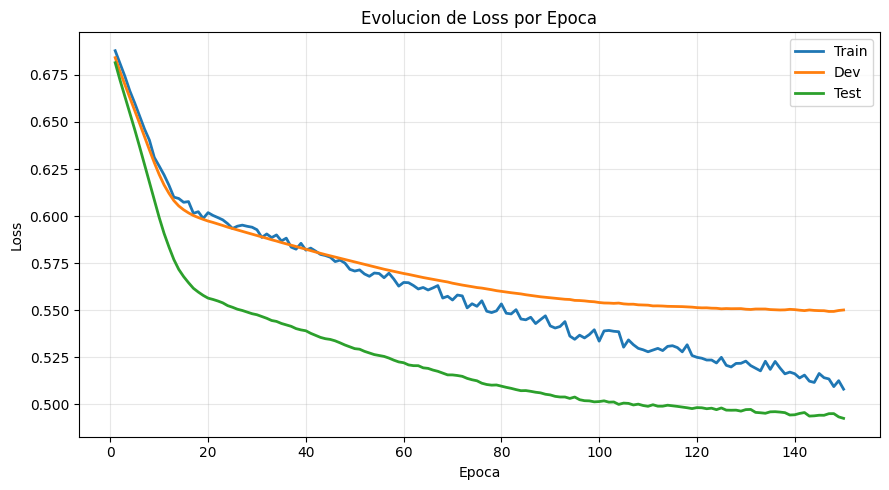

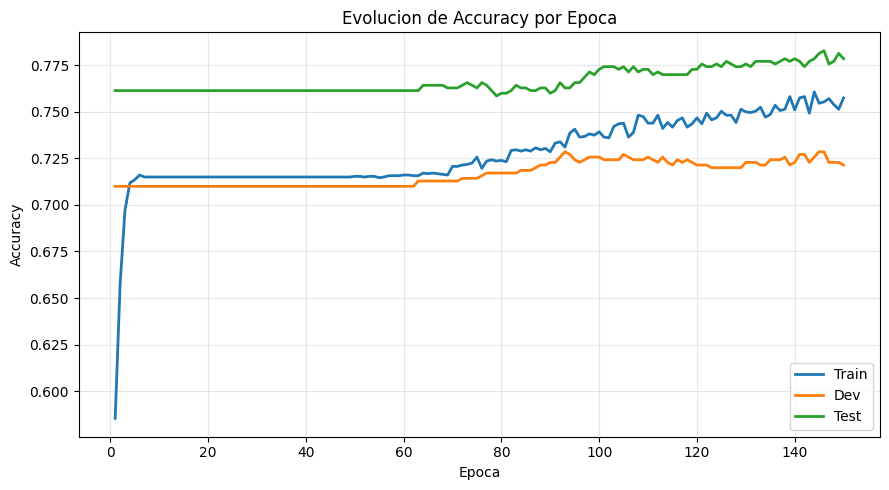

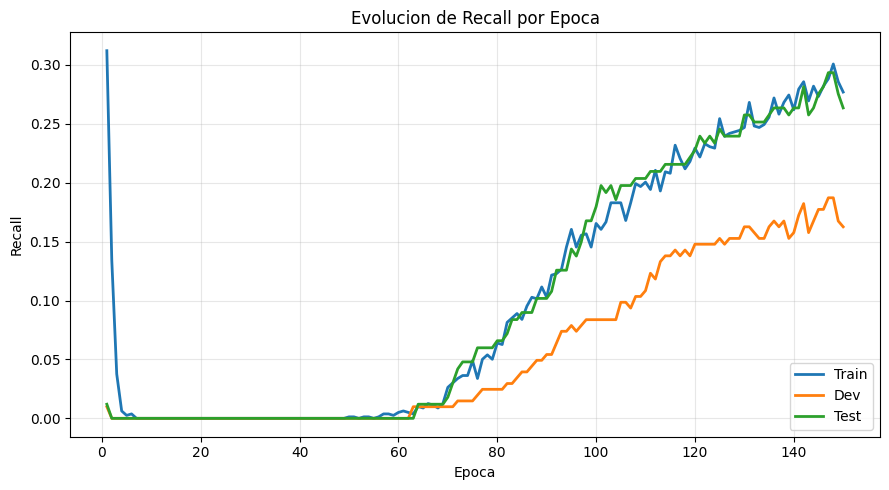

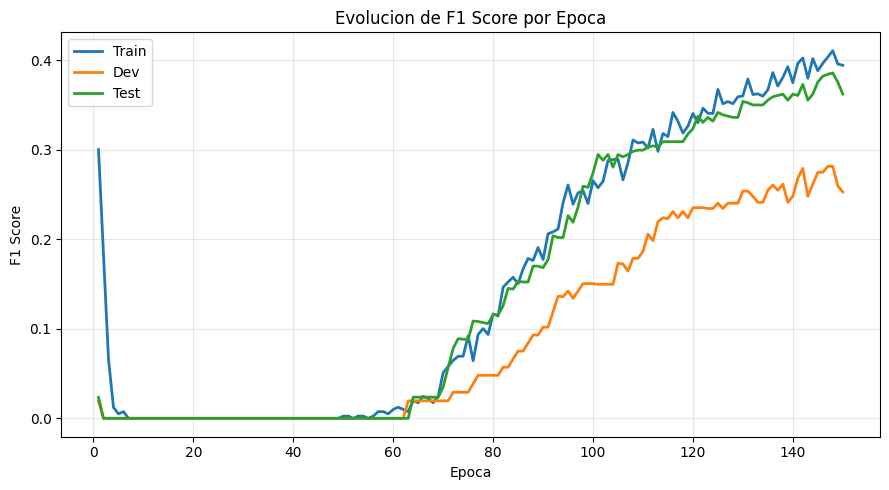

In [6]:
# MLP para clasificacion binaria usando embeddings precomputados
import copy
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# 1) Conversion de numpy -> tensores
X_train_t = torch.tensor(X_train_pre, dtype=torch.float32)
y_train_t = torch.tensor(train_labels, dtype=torch.long)
X_dev_t = torch.tensor(X_dev_pre, dtype=torch.float32)
y_dev_t = torch.tensor(dev_labels, dtype=torch.long)
X_test_t = torch.tensor(X_test_pre, dtype=torch.float32)
y_test_t = torch.tensor(test_labels, dtype=torch.long)

# 2) DataLoaders
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(TensorDataset(X_dev_t, y_dev_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

# 3) Definicion del MLP
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 64), dropout=0.5, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], num_classes),
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_pre.shape[1]
model = MLPClassifier(input_dim=input_dim, hidden_dims=(256,64), dropout=0.5, num_classes=2)

# 4) Configuracion de entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)
num_epochs = 150

# Configuracion de dispositivo (GPU si esta disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Funcion auxiliar para evaluar un split (dev/test/train)
def evaluate_split(model, dataloader):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds, pos_label=1)
    f1 = f1_score(all_labels, all_preds, pos_label=1)
    return avg_loss, acc, recall, f1

# 5) Historial de metricas por epoca para luego graficar
history = {
    "epoch": [],
    "train_loss": [], "train_acc": [], "train_recall": [], "train_f1": [],
    "dev_loss": [], "dev_acc": [], "dev_recall": [], "dev_f1": [],
    "test_loss": [], "test_acc": [], "test_recall": [], "test_f1": [],
}

best_state = None
best_dev_acc = -1.0

# 6) Bucle de entrenamiento
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_preds, train_labels_epoch = [], []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_preds.extend(preds.detach().cpu().numpy())
        train_labels_epoch.extend(labels.detach().cpu().numpy())

    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_labels_epoch, train_preds)
    epoch_train_recall = recall_score(train_labels_epoch, train_preds, pos_label=1)
    epoch_train_f1 = f1_score(train_labels_epoch, train_preds, pos_label=1)

    epoch_dev_loss, epoch_dev_acc, epoch_dev_recall, epoch_dev_f1 = evaluate_split(model, dev_loader)
    epoch_test_loss, epoch_test_acc, epoch_test_recall, epoch_test_f1 = evaluate_split(model, test_loader)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)
    history["train_recall"].append(epoch_train_recall)
    history["train_f1"].append(epoch_train_f1)
    history["dev_loss"].append(epoch_dev_loss)
    history["dev_acc"].append(epoch_dev_acc)
    history["dev_recall"].append(epoch_dev_recall)
    history["dev_f1"].append(epoch_dev_f1)
    history["test_loss"].append(epoch_test_loss)
    history["test_acc"].append(epoch_test_acc)
    history["test_recall"].append(epoch_test_recall)
    history["test_f1"].append(epoch_test_f1)

    # Guardamos el mejor modelo segun ACC en dev
    if epoch_dev_acc > best_dev_acc:
        best_dev_acc = epoch_dev_acc
        best_state = copy.deepcopy(model.state_dict())

    # Impresion solo en epocas multiplos de 10 (durante training)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:03d}/{num_epochs:03d} | "
            f"Train -> loss: {epoch_train_loss:.4f}, acc: {epoch_train_acc:.4f}, recall: {epoch_train_recall:.4f}, f1: {epoch_train_f1:.4f} | "
            f"Dev -> loss: {epoch_dev_loss:.4f}, acc: {epoch_dev_acc:.4f}, recall: {epoch_dev_recall:.4f}, f1: {epoch_dev_f1:.4f} | "
        )

# Convertimos listas a arrays para facilitar graficas
history = {k: np.array(v) for k, v in history.items()}

# 7) Etapa final de test con el mejor modelo segun dev ACC
model.load_state_dict(best_state)
test_loss, test_acc, test_recall, test_f1 = evaluate_split(model, test_loader)

print("Entrenamiento finalizado.")
print(f"Epocas guardadas en history: {len(history['epoch'])}")
print("Vectores disponibles para graficar: train/dev/test x loss/acc/recall/f1")
print(f"Test final (mejor modelo por dev ACC) -> loss: {test_loss:.4f}, acc: {test_acc:.4f}, recall: {test_recall:.4f}, f1: {test_f1:.4f}")

# Eje X: epocas
epochs = history["epoch"]

# Definimos las metricas a graficar
metrics = [
    ("loss", "Loss"),
    ("acc", "Accuracy"),
    ("recall", "Recall"),
    ("f1", "F1 Score"),
]

for metric_key, metric_name in metrics:
    plt.figure(figsize=(9, 5))
    plt.plot(epochs, history[f"train_{metric_key}"], label="Train", linewidth=2)
    plt.plot(epochs, history[f"dev_{metric_key}"], label="Dev", linewidth=2)
    plt.plot(epochs, history[f"test_{metric_key}"], label="Test", linewidth=2)

    plt.title(f"Evolucion de {metric_name} por Epoca")
    plt.xlabel("Epoca")
    plt.ylabel(metric_name)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva. Incluya también una matriz de confusión.

---



=== Evaluacion en DEV ===
Accuracy:        0.7286
Macro-Precision: 0.8035
Macro-Recall:    0.5349
Macro-F1:        0.4877
-
Precision (+):   0.8824
Recall (+):      0.0739
F1 (+):          0.1364


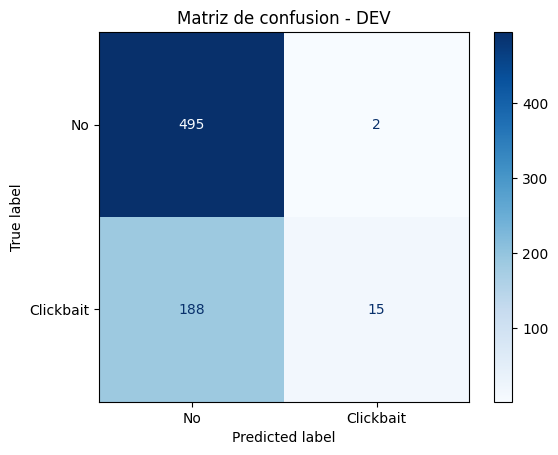

In [7]:
# Evaluacion final sobre DEV
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

# 1) Obtener predicciones del modelo sobre el split de desarrollo
model.eval()
dev_preds = []
dev_true = []

with torch.no_grad():
    for inputs, labels in dev_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        dev_preds.extend(preds)
        dev_true.extend(labels.numpy())

dev_preds = np.array(dev_preds)
dev_true = np.array(dev_true)

# 2) Metricas globales solicitadas
dev_acc = accuracy_score(dev_true, dev_preds)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    dev_true, dev_preds, average="macro", zero_division=0
)

# 3) Metricas de la clase positiva (Clickbait = 1)
pos_p, pos_r, pos_f1, _ = precision_recall_fscore_support(
    dev_true, dev_preds, average="binary", pos_label=1, zero_division=0
)

print("=== Evaluacion en DEV ===")
print(f"Accuracy:        {dev_acc:.4f}")
print(f"Macro-Precision: {macro_p:.4f}")
print(f"Macro-Recall:    {macro_r:.4f}")
print(f"Macro-F1:        {macro_f1:.4f}")
print("-")
print(f"Precision (+):   {pos_p:.4f}")
print(f"Recall (+):      {pos_r:.4f}")
print(f"F1 (+):          {pos_f1:.4f}")

# 4) Matriz de confusion
cm_dev = confusion_matrix(dev_true, dev_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dev, display_labels=CLICKBAIT_LABELS)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusion - DEV")
plt.grid(False)
plt.show()

**Descripción del modelo**:

Se implementó un clasificador binario tipo **MLP (Multi-Layer Perceptron)** para detectar clickbait a partir del texto del titular.

**Pretratamiento:**
- Cada tweet se normaliza a minúsculas, se eliminan acentos y se filtran stop words en español.
- El texto se representa como el **centroide de embeddings preentrenados**: promedio de los vectores de las palabras del titular.
- Se usó el modelo preentrenado `glove-wiki-gigaword-200`, por lo que la dimensión de entrada del MLP es 200.
- Si un titular no tiene palabras presentes en el vocabulario del embedding, se usa un vector cero.

**Arquitectura de la red:**
- Capa de entrada: 200 unidades.
- Capas ocultas fully-connected: 256 -> 64
- Función de activación en capas ocultas: ReLU.
- Regularización: Dropout (p=0.5) entre capas.
- Capa de salida: 2 neuronas (clases `No` y `Clickbait`).

**Configuración de entrenamiento:**
- Framework: PyTorch.
- Función de pérdida: CrossEntropyLoss.
- Optimizador: Adam (`lr=1e-4`, `weight_decay=1e-5`).
- Tamaño de batch: 256.
- Número máximo de épocas: 100.

**Selección del mejor modelo:**
- Durante entrenamiento se calculan métricas por época en train/dev/test: loss, accuracy, recall y F1.
- Se conserva el checkpoint con mejor **Accuracy en dev** (`best_dev_acc`).
- El modelo final reportado en test corresponde a ese mejor checkpoint.

**Métricas reportadas:**
- Se almacenan por época en `history`: `loss`, `acc`, `recall`, `f1` para train/dev/test.
- Se generan curvas de evolución por época para analizar ajuste y generalización (detección de overfitting).

**Observación metodológica:**
- Este enfoque sigue la consigna de no entrenar embeddings propios y usar embeddings preentrenados como entrada al clasificador.

## Parte 2

Utilizando pytorch, construir un clasificador utilizando una arquitectura LSTM que clasifique los textos en clickbait o no clickbait.
Se deben utilizar **word embeddings** para representar cada palabra de los textos como entrada de la red.

**Sugerencias:**
* Puede utilizar los mismos word embeddings de la parte 1.
* Se recomienda usar como referencia el taller de LSTM, pero debe adaptar la arquitectura para que funcione como clasificador en lugar de etiquetado secuencial.
  * Para ello se recomienda tomar la capa oculta correspondiente a la última palabra que **no** es un token PAD (tener cuidado con el manejo de los batches).
  * Otra opción posible es tomar el promedio de las capas ocultas descartando las correspondientes a tokens PAD.
* Tener cuidado con el manejo de batches, siendo consistente con la flag de batch_first (en la definición de la capa LSTM de la red así como en la collate_fn del DataLoader).
* Usar el optimizador Adam en lugar de SGD.

In [ ]:
# su código aquí


Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva. Incluya también una matriz de confusión.


In [ ]:
# su código aquí


**Descripción del modelo**:

...

## Parte 3 (opcional):
Elija uno de los clasificadores anteriores y realice una búsqueda automatizada de hiperparámetros del modelo. Por ejemplo, puede utilizar una búsqueda en grilla completa o una búsqueda aleatoria, eligiendo diferente cantidad de capas, número unidades por capa, funciones de activación, y valores de learning rate. Intente encontrar el mejor clasificador posible, comparándolos sobre el corpus de **dev**.

In [ ]:
# su código aquí


Describa las características de su mejor modelo, incluyendo arquitectura e hiperparámetros. Evalúelo sobre el corpus de **dev**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva. Incluya también una matriz de confusión.

In [ ]:
# su código aquí


**Descripción del modelo**:

...

## Parte 4:

Elija el mejor clasificador de todos los construidos en las partes anteriores, comparándolos utilizando la medida macro-F1, y evalúelo sobre el corpus de **test**, imprimiendo la métrica accuracy, y las métricas macro-precision, macro-recall y macro-F1, así como precision, recall y F1 de la clase positiva.

In [ ]:
# su código aquí


Despliegue la matriz de confusión sobre el corpus de **test** para el mejor clasificador construido en las partes anteriores.

In [ ]:
# su código aquí


Analice los resultados, y responda, al menos, las siguientes preguntas:

1.   ¿Cuál fue la arquitectura que funcionó mejor? Describa brevemente sus características.
2.   ¿Cuál es la forma del modelo? Indique cantidad de capas, unidades, funciones de activación, etc. Puede usar el método print() sobre el modelo para imprimir la forma del modelo.
3.   ¿Cuáles fueron las mayores dificultades encontradas en el desarrollo del laboratorio? Describa las dificultades encontradas así como la forma en que fueron remediadas.

(sus respuestas aquí)
